In [2]:
import matplotlib.pyplot as plt
import numpy as np
import h5py
import os
import capillary_wave_analysis as cwa
import PSD_utils
from scipy.signal import welch

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
plt.rc("axes.spines", right=True, top=True)
plt.rc("font", family="serif")
plt.rc("legend", edgecolor="none", frameon=False)

log2_xticks = np.array([8, 16, 32, 64], dtype=float)    # x ticks for log2 scale

import warnings
warnings.filterwarnings("ignore")

In [5]:
# Load all 1D data for 0.30vpp datasets (10 sets)
import string

base = "/disk/hyk049/DHM_new_1Dcenter/"

def h5read_T(fname, dset):
    with h5py.File(fname, "r") as f:
        return np.array(f[dset])

t = h5read_T(base + "Q_1D_0vpp_a.h5", "/t")
x = h5read_T(base + "Q_1D_0vpp_a.h5", "/x")
nx = len(x)

labels = list("abcdefghij")

# Load all Q matrices
Q = {}
for lbl in labels:
    fname = f"{base}Q_1D_0vpp_{lbl}.h5"
    Q[lbl] = h5read_T(fname, "/Q_1D")
    

In [6]:
dt = t[1] - t[0]
t_dep = 0.05
seg_len = int(t_dep//dt)+1
num_segs = len(t)//seg_len

Q_a = Q["a"]
nx, nt = Q_a.shape
t_new = seg_len * num_segs

Q_a_split = np.split(Q_a[:,:t_new], num_segs, axis=1)

Spectral slope (total t): -2.85
r2 score (total t): 1.00


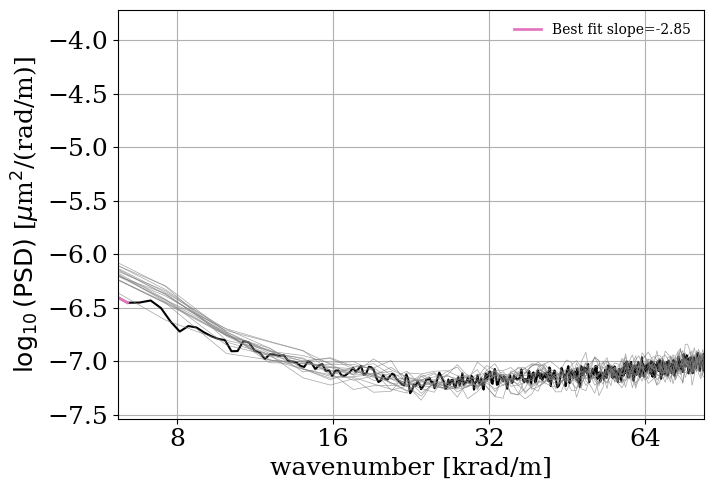

In [7]:
FS_DHM = 115_200
min_pts = 10
target_segments_full = 100

i = 100  # PSD at the center point

plt.figure(figsize=(7,5))

# PSD
k_all, psd_all, f_all, slope, r2, i_best, j_best = PSD_utils.compute_PSD(Q_a[i,:], FS_DHM, min_pts, target_segments_full)
print(f"Spectral slope (total t): {slope:.2f}")
print(f"r2 score (total t): {r2:.2f}")

plt.plot(k_all, psd_all, lw=1.5, color='k')

# Highlight the best linear fit segment
if i_best is not None and j_best is not None:
    plt.plot(k_all[i_best:j_best+1], psd_all[i_best:j_best+1],
             lw=2, color='C6', label=f'Best fit slope={slope:.2f}')

for k in range(len(Q_a_split)):
    k, psd, f, slope, r2, i_best, j_best = PSD_utils.compute_PSD(Q_a_split[k][i,:], FS_DHM, min_pts, target_segments_full)
    plt.plot(k, psd, lw=0.5, alpha=0.7, color='C7')

plt.xscale('log', base=2)
plt.xlim(log2_xticks.min()/1.3, log2_xticks.max()*1.3)

ax = plt.gca()
ax.set_xticks(log2_xticks)
ax.set_xticklabels([str(int(x)) for x in log2_xticks], fontsize=18)

plt.tick_params(axis='y', labelsize=18)
plt.xlabel("wavenumber [krad/m]", fontsize=18)
plt.ylabel(r"$\log_{10}(\mathrm{PSD})$ [$\mu$m$^2$/(rad/m)]", fontsize=18)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


Spectral slope (total t): -2.85
r2 score (total t): 1.00


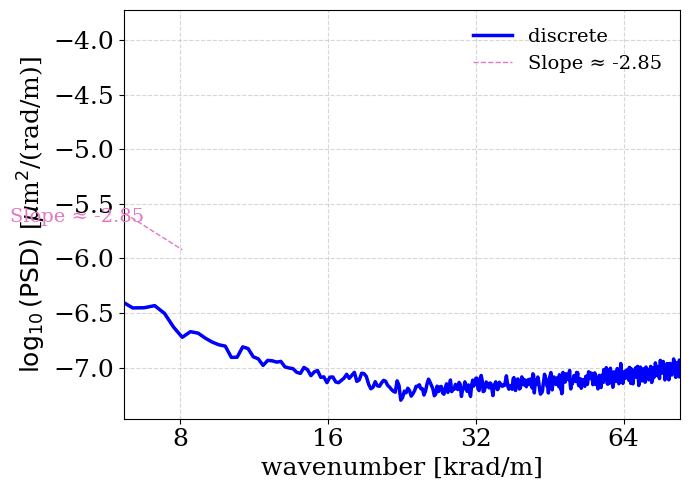

In [12]:
FS_DHM = 115_200
i = 100

plt.figure(figsize=(7, 5))

# PSD
k_all, psd_all, f_all, slope, r2, i_best, j_best = PSD_utils.compute_PSD(Q_a[i, :], FS_DHM, min_pts, target_segments_full)
print(f"Spectral slope (total t): {slope:.2f}")
print(f"r2 score (total t): {r2:.2f}")

plt.plot(k_all, psd_all, lw=1.5, color='k')

# ---- Welch PSD (Hann, 50% overlap, ~100 segments) ----
n = len(Q_a[i, :])
target_segments = 100
nperseg = max(256, int(2*n/(target_segments+1)))  
if nperseg % 2:
    nperseg -= 1

# Compute PSD
# -> spectral slope estimation
# -> inertial range identification
f, S_f = welch(Q_a[i, :], fs=FS_DHM, window="hann", nperseg=nperseg, noverlap=nperseg//2,
                return_onesided=True, scaling="density")

if f.size and f[0] == 0.0:
    f   = f[1:]
    S_f = S_f[1:]

# f -> k & Sf -> Sk
k = cwa.get_wavenumbers(f)
df_dk = PSD_utils.df_dk_from_k(k)
df_dk = np.where(np.isfinite(df_dk), df_dk, 0.0)
S_k = S_f * np.abs(df_dk)

log10_psd = np.log10(S_k)
k_krad = k / 1000.0
k_log2 = np.log2(k_krad)

in_range = (k_krad >= PSD_utils.XMIN_RAW) & (k_krad <= PSD_utils.XMAX_RAW) & np.isfinite(k_log2)
k_log2 = k_log2[in_range]
k_krad = k_krad[in_range]
log10_psd = log10_psd[in_range]


# Amplitude spectrum (for regimes)
f_amp, amp_um = PSD_utils.amplitude_welch(Q_a[i, :], FS_DHM)

# Welch amplitude
amp_um_full = np.interp(f, f_amp, amp_um)
amp_um_full = amp_um_full[in_range]         
f_used = f[in_range]   

# Regime classification
kv, is_disc, is_meso, is_kin, is_str = cwa.get_regime_idxs(f_used, amp_um_full, no_strong=False)

# plot PSD by regime
regimes = [
    (is_disc, 'blue',   'discrete'),
    (is_meso, 'orange', 'mesoscopic'),
    (is_kin,  'green',  'kinetic'),
    (is_str,  'red',    'strong'),
]

for mask, color, label in regimes:
    if np.any(mask):
        plt.plot(k_krad[mask], log10_psd[mask],
                 lw=2.5, color=color, label=label)
        
# --- Plot best-fit linear slope as a straight line above the colored PSD ---
if i_best is not None and j_best is not None:
    k_fit = k_krad[i_best:j_best+1]
    psd_fit = psd_all[i_best:j_best+1]

    # --- Dotted straight line showing slope ---
    # y = slope * (log10(k) - log10(k0)) + log10(S0)
    k0 = k_fit[0]
    S0 = psd_fit[0]
    slope_line = slope * (np.log10(k_fit) - np.log10(k0)) + S0
    plt.plot(k_fit, slope_line, 'C6--', lw=1, label=f"Slope ≈ {slope:.2f}")

    # Annotate slope above the line
    mid_idx = len(k_fit)//2
    plt.text(k_fit[mid_idx], slope_line[mid_idx] + 0.05*(slope_line.max()-slope_line.min()),
             f"Slope ≈ {slope:.2f}", color='C6', fontsize=14, ha='right')
    
plt.xscale('log', base=2)
plt.xlim(log2_xticks.min()/1.3, log2_xticks.max()*1.3)

ax = plt.gca()
ax.set_xticks(log2_xticks)
ax.set_xticklabels([str(int(x)) for x in log2_xticks], fontsize=18)

plt.tick_params(axis='y', labelsize=18)
plt.xlabel("wavenumber [krad/m]", fontsize=18)
plt.ylabel(r"$\log_{10}(\mathrm{PSD})$ [$\mu$m$^2$/(rad/m)]", fontsize=18)
plt.legend(fontsize=14)
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.tight_layout()
plt.show()


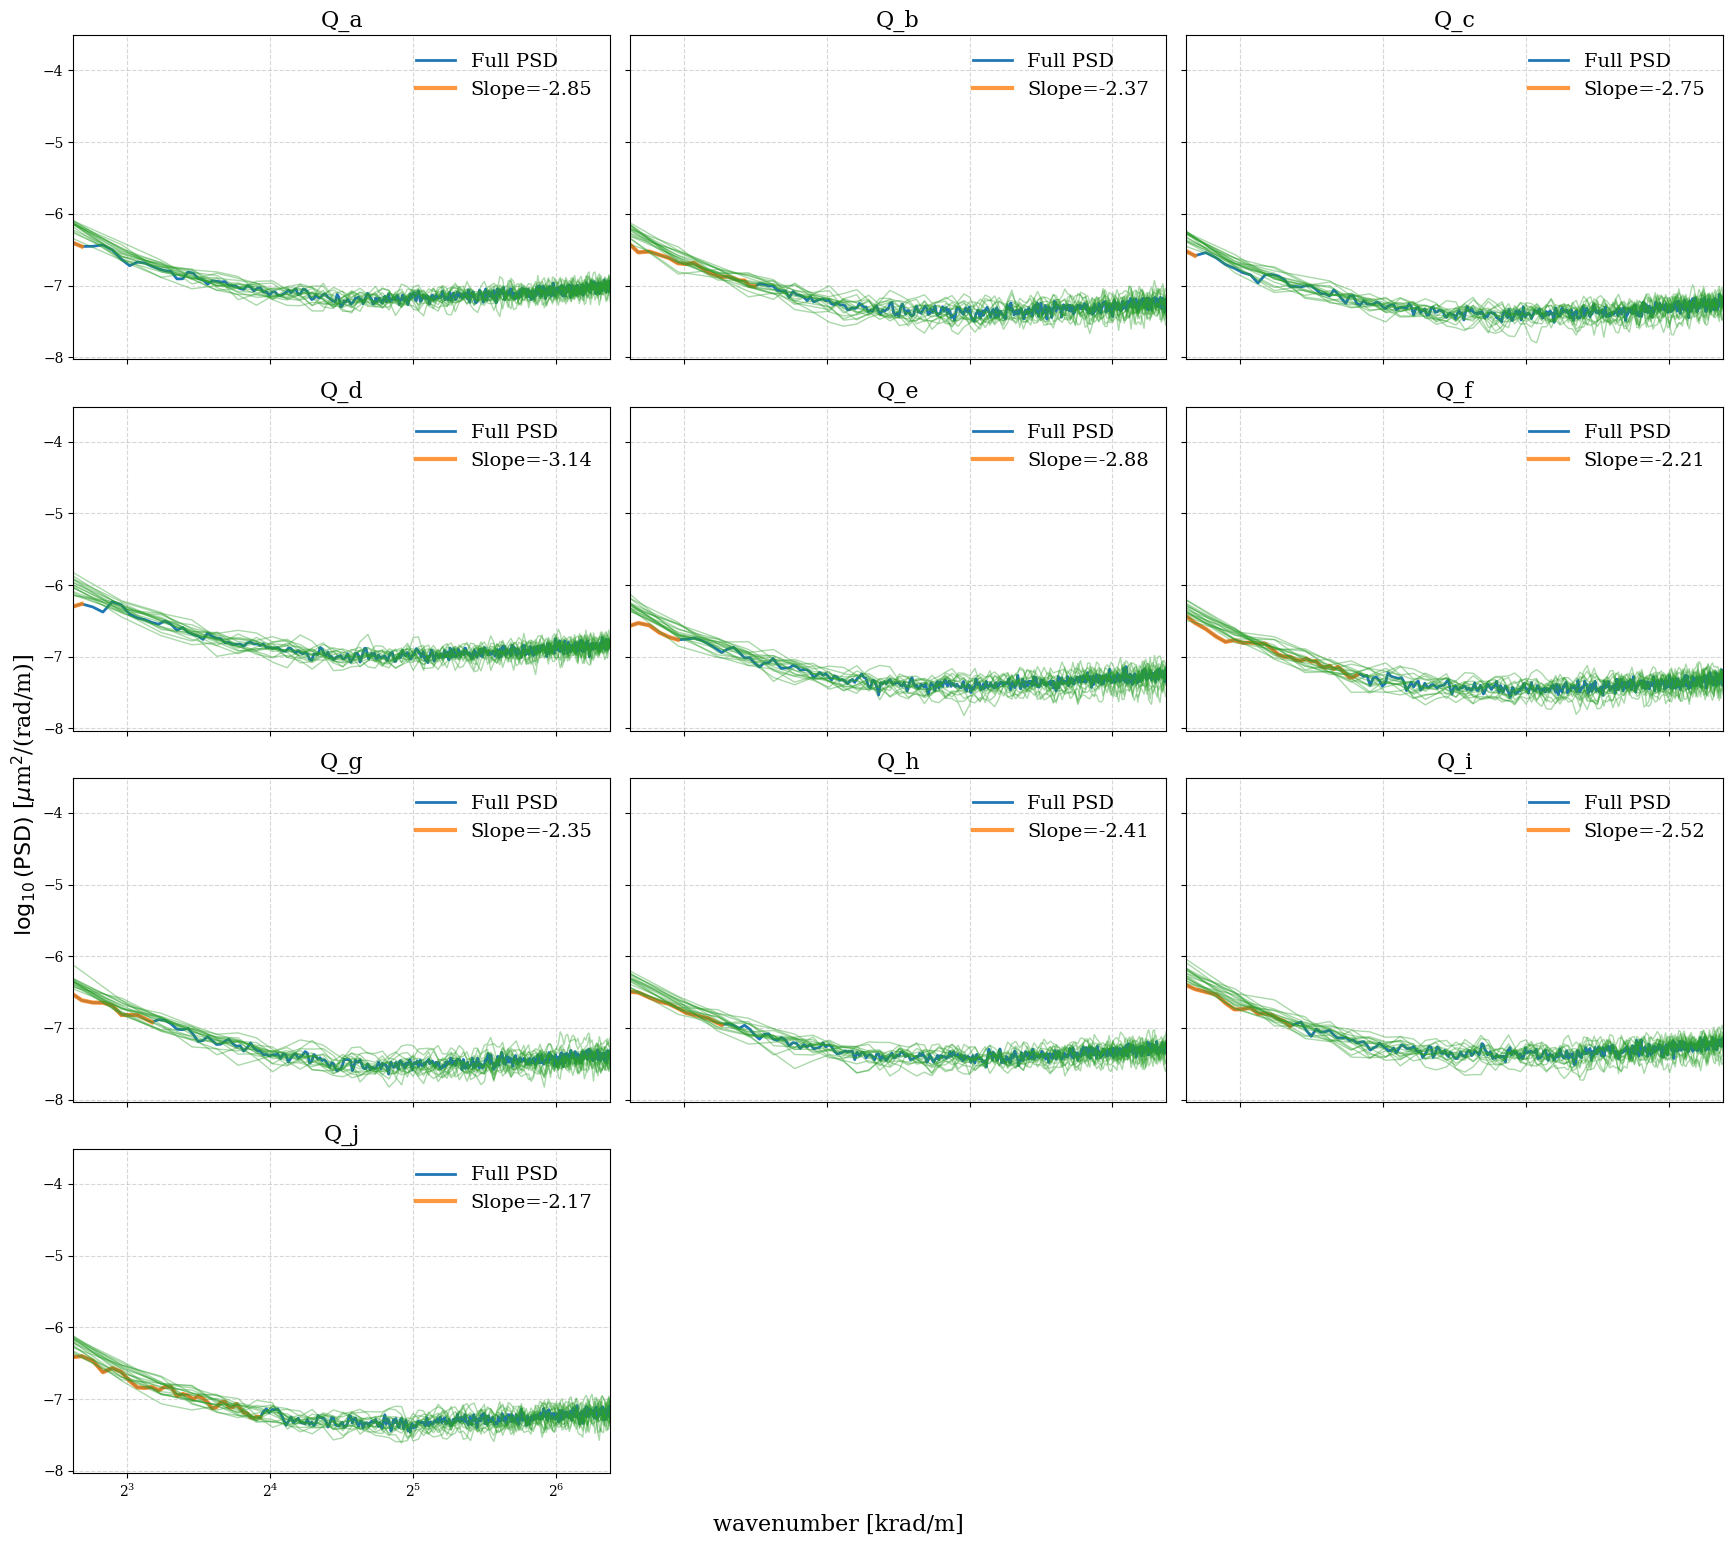

In [13]:
FS_DHM = 115_200
dt = t[1] - t[0]
t_dep = 0.05        # temporal independence interval
seg_len = int(t_dep//dt) + 1
num_segs = len(t)//seg_len
i_center = 100

target_segments_full = 100
target_segments_seg = 30

labels = list(Q.keys())
n_plots = len(labels)

# Determine grid size for subplots
ncols = 3
nrows = int(np.ceil(n_plots / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows), sharex=True, sharey=True)
axes = axes.flatten()

slopes = []

for idx, lbl in enumerate(labels):
    ax = axes[idx]
    Q_mat = Q[lbl]
    nx, nt = Q_mat.shape
    t_new = seg_len * num_segs
    Q_split = np.split(Q_mat[:, :t_new], num_segs, axis=1)
    
    # Full PSD
    k_all, psd_all, f_all, slope, r2, i_best, j_best = PSD_utils.compute_PSD(Q_mat[i_center,:], FS_DHM, min_pts, target_segments)
    ax.plot(k_all, psd_all, lw=2, color='C0', label='Full PSD')
    
    slopes.append(slope)
    
    # Highlight best linear fit
    if i_best is not None and j_best is not None:
        ax.plot(k_all[i_best:j_best+1], psd_all[i_best:j_best+1],
                lw=3, color='C1', alpha=0.8, label=f'Slope={slope:.2f}')
    
    # Plot segmented PSDs
    for seg in Q_split:
        k_seg, psd_seg, f_seg, _, _, _, _ = PSD_utils.compute_PSD(seg[i_center,:], FS_DHM, min_pts, target_segments_seg)
        ax.plot(k_seg, psd_seg, lw=1, alpha=0.4, color='C2')
    
    ax.set_xscale('log', base=2)
    ax.set_xlim(log2_xticks.min()/1.3, log2_xticks.max()*1.3)
    ax.set_title(f"Q_{lbl}", fontsize=16)
    ax.grid(True, which='both', ls='--', alpha=0.5)
    ax.legend(fontsize=14)

# Remove empty axes if any
for j in range(idx+1, len(axes)):
    fig.delaxes(axes[j])

fig.text(0.5, 0.04, "wavenumber [krad/m]", ha='center', fontsize=16)
fig.text(0.04, 0.5, r"$\log_{10}(\mathrm{PSD})$ [$\mu$m$^2$/(rad/m)]", va='center', rotation='vertical', fontsize=16)
plt.tight_layout(rect=[0.05, 0.05, 1, 1])
plt.show()


In [14]:
Q_stack_all = []

for lbl in labels:
    Q_mat = Q[lbl]
    nx, nt = Q_mat.shape
    t_new = seg_len * num_segs
    Q_split = np.split(Q_mat[:, :t_new], num_segs, axis=1)
    Q_stack = np.stack(Q_split, axis=1)
    
    Q_stack_all.append(Q_stack)

Q_stack_all = np.stack(Q_stack_all, axis=1)
Q_stack_all = Q_stack_all.reshape(nx, len(Q)*num_segs, seg_len)

In [15]:
Q_subspace = np.mean(Q_stack_all, axis=1)

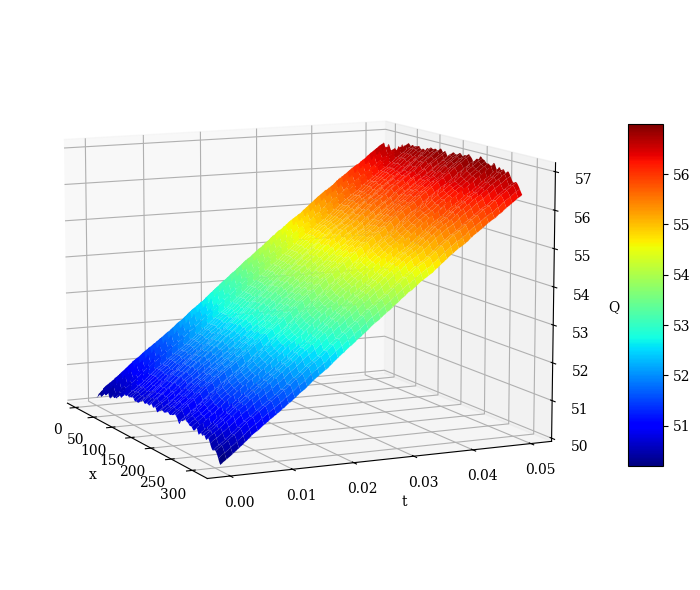

In [16]:
from mpl_toolkits.mplot3d import Axes3D

tt = t[:seg_len]

TT, XX = np.meshgrid(tt, x)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(XX, TT, Q_subspace,
                       cmap='jet',
                       edgecolor='none')

ax.set_xlabel("x")
ax.set_ylabel("t")
ax.set_zlabel("Q")
ax.view_init(elev=10, azim=-25)

fig.colorbar(surf, shrink=0.6, aspect=10)

plt.tight_layout()
plt.show()

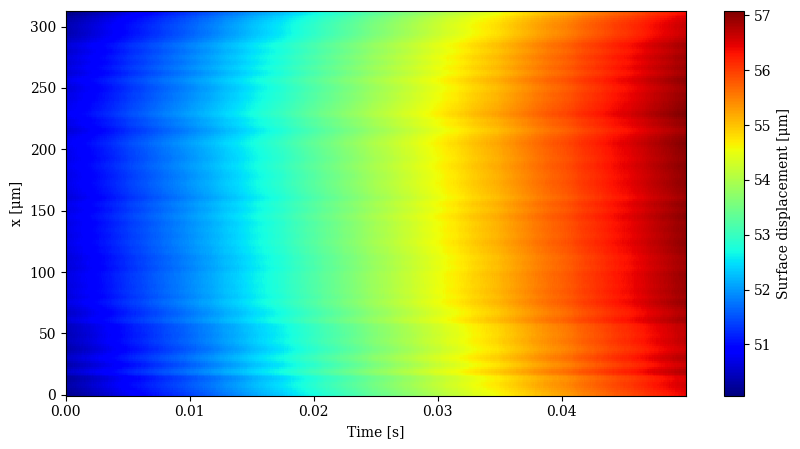

In [17]:
plt.figure(figsize=(10,5))
plt.pcolormesh(TT, XX, Q_subspace, shading='auto', cmap='jet')
plt.xlabel('Time [s]')
plt.ylabel('x [μm]')
plt.colorbar(label='Surface displacement [μm]')
plt.show()

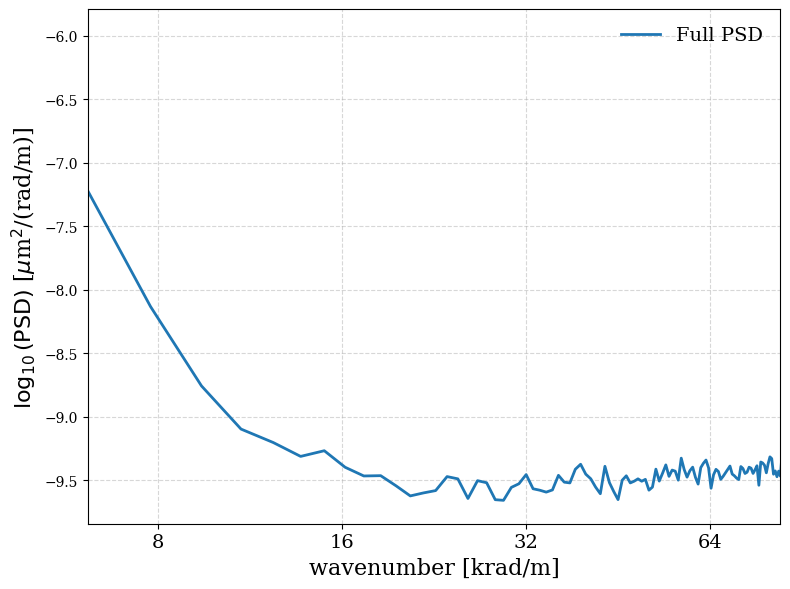

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))

# Full PSD
k_all, psd_all, f_all, *_ = \
    PSD_utils.compute_PSD(Q_subspace[i_center, :], FS_DHM, min_pts, 30)
ax.plot(k_all, psd_all, lw=2, color='C0', label='Full PSD')

ax.set_xscale('log', base=2)
ax.set_xlim(log2_xticks.min()/1.3, log2_xticks.max()*1.3)

ax.grid(True, which='both', ls='--', alpha=0.5)
ax.legend(fontsize=14)

# Proper tick formatting
ax.set_xticks(log2_xticks)
ax.set_xticklabels([str(int(x)) for x in log2_xticks], fontsize=14)

ax.set_xlabel("wavenumber [krad/m]", fontsize=16)
ax.set_ylabel(r"$\log_{10}(\mathrm{PSD})$ [$\mu$m$^2$/(rad/m)]",
              fontsize=16)

plt.tight_layout()
plt.show()

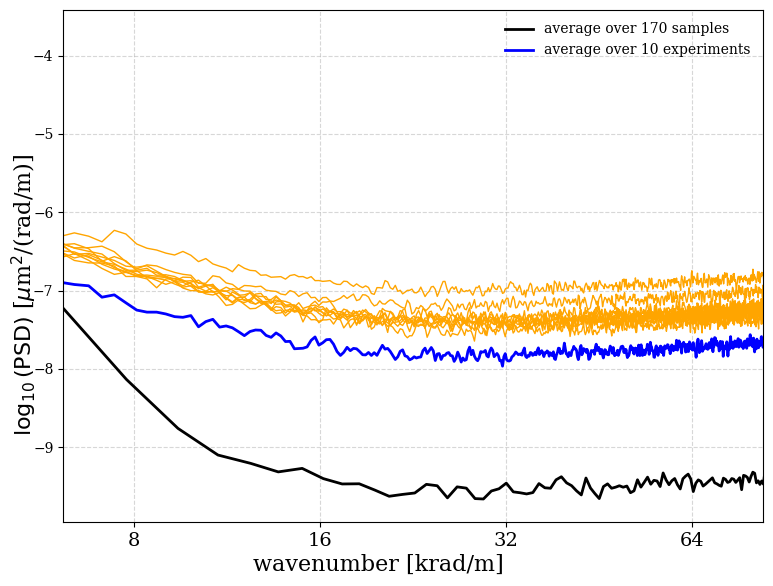

In [19]:
FS_DHM = 115_200
dt = t[1] - t[0]
t_dep = 0.05        # temporal independence interval
seg_len = int(t_dep//dt) + 1
num_segs = len(t)//seg_len
i_center = 100

target_segments_full = 100
target_segments_seg = 100

labels = list(Q.keys())

fig, ax = plt.subplots(figsize=(8, 6))
for idx, lbl in enumerate(labels):
    Q_mat = Q[lbl]

    if idx == 0:
        Q_avg = Q_mat
    else:
        Q_avg = (Q_avg + Q_mat)/2
    
    # Full PSD
    k_exp, psd_exp, *_ = PSD_utils.compute_PSD(Q_mat[i_center,:], FS_DHM, min_pts, target_segments)
    ax.plot(k_exp, psd_exp, color='orange', lw=1.0)
    
    ax.set_xscale('log', base=2)
    ax.set_xlim(log2_xticks.min()/1.3, log2_xticks.max()*1.3)
    ax.grid(True, which='both', ls='--', alpha=0.5)
    ax.legend(fontsize=14)


ax.plot(k_all, psd_all, lw=2, color='k', label='average over 170 samples')

k_avg, psd_avg, *_ = PSD_utils.compute_PSD(Q_avg[i_center,:], FS_DHM, min_pts, target_segments)
ax.plot(k_avg, psd_avg, lw=2, color='b', label='average over 10 experiments')


ax.set_xticks(log2_xticks)
ax.set_xticklabels([str(int(x)) for x in log2_xticks], fontsize=14)
fig.text(0.5, 0.04, "wavenumber [krad/m]", ha='center', fontsize=16)
fig.text(0.04, 0.5, r"$\log_{10}(\mathrm{PSD})$ [$\mu$m$^2$/(rad/m)]", va='center', rotation='vertical', fontsize=16)
plt.tight_layout(rect=[0.05, 0.05, 1, 1])
plt.legend()
plt.show()


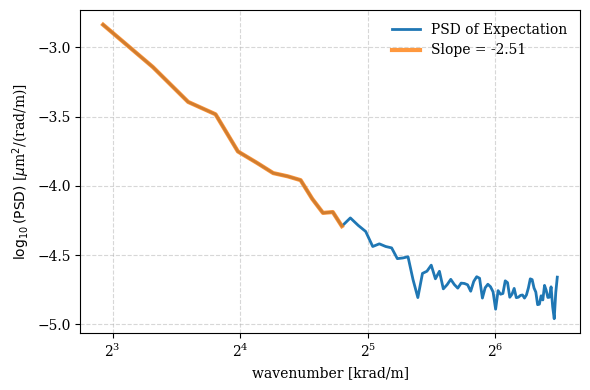

In [9]:
FS_DHM = 115_200
dt = t[1] - t[0]
t_dep = 0.05        # temporal independence interval
seg_len = int(t_dep//dt) + 1
num_segs = len(t)//seg_len
i_center = 100

Q_mean = []
for idx, lbl in enumerate(labels):
    Q_mat = Q[lbl]
    nx, nt = Q_mat.shape
    t_new = seg_len * num_segs
    Q_split = np.split(Q_mat[:, :t_new], num_segs, axis=1)
    
    Q_stack = np.stack(Q_split, axis=0)
    Q_seg_mean = np.mean(Q_stack, axis=0)
    Q_mean.append(Q_seg_mean)
    
Q_mean = np.stack(Q_mean, axis=0)
EFOM = np.mean(Q_mean, axis=0)

k_all, psd_all, slope, r2, i_best, j_best = PSD_utils.compute_PSD(EFOM[i_center, :], FS_DHM)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(k_all, psd_all, lw=2, color='C0', label='PSD of Expectation')

if i_best is not None and j_best is not None:
    ax.plot(k_all[i_best:j_best+1], psd_all[i_best:j_best+1],
            lw=3, color='C1', alpha=0.8, label=f'Slope = {slope:.2f}')

ax.set_xscale('log', base=2)
ax.set_xlabel('wavenumber [krad/m]')
ax.set_ylabel(r'$\log_{10}(\mathrm{PSD})$ [$\mu$m$^2$/(rad/m)]')
ax.grid(True, which='both', ls='--', alpha=0.5)
ax.legend()

plt.tight_layout()
plt.show()
